In [1]:
import random 
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter,sosfiltfilt,savgol_filter,find_peaks
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

In [2]:
FS=125 
WINDOW_SECONDS=8 
WINDOW_SIZE=WINDOW_SECONDS*FS
STEP_SECONDS=4 
STEP_SIZE=STEP_SECONDS*FS
PATIENT_IDS=[1,2,3,4,5]



In [3]:
FS = 125                 # PPG sampling frequency
WINDOW_SECONDS = 8       # Each PPG sample/window is 8 seconds
WINDOW_SIZE = FS * WINDOW_SECONDS
STEP_SECONDS = 4
STEP_SIZE = FS * STEP_SECONDS

# Small classroom demo: first 5 patient records
PATIENT_IDS = [1, 2, 3, 4, 5]

BASE_URL = (
    "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"
)

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SECONDS, "seconds")
print("Samples per window:", WINDOW_SIZE)

Sampling frequency: 125 Hz
Window size: 8 seconds
Samples per window: 1000


In [4]:
def load_patient(patient_id):
    """
    Load a single patient record from the BIDMC dataset.
    """
    signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
    numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
    signals = pd.read_csv(signal_url)
    numerics = pd.read_csv(numeric_url)
    signals.columns=signals.columns.str.strip()
    numerics.columns=numerics.columns.str.strip()
    return signals, numerics
all_patient_data=[]
for patient_id in PATIENT_IDS:
    signals, numerics = load_patient(patient_id)
    all_patient_data.append({
        "patient_id": patient_id,
        "signals": signals,
        "numerics": numerics,
    })
    print(f"Loaded patient {patient_id}: {signals.shape[0]} samples, {numerics.shape[0]} numeric records")

Loaded patient 1: 60001 samples, 481 numeric records
Loaded patient 2: 60001 samples, 481 numeric records
Loaded patient 3: 60001 samples, 481 numeric records
Loaded patient 4: 60001 samples, 481 numeric records
Loaded patient 5: 60001 samples, 481 numeric records


In [5]:
example_signals=all_patient_data[1]['signals']
example_numerics=all_patient_data[1]['numerics']

print(example_signals.columns.tolist())
print(example_numerics.columns.tolist())
print(example_signals.head())
print(example_numerics.head())

['Time [s]', 'II', 'PLETH', 'RESP', 'V', 'AVR']
['Time [s]', 'HR', 'PULSE', 'RESP', 'SpO2']
   Time [s]       II    PLETH     RESP        V      AVR
0     0.000  0.14453  0.63636  0.04059  0.83529  0.74414
1     0.008  0.15625  0.65689  0.04059  0.83529  0.74023
2     0.016  0.15625  0.67351  0.04059  0.84118  0.74023
3     0.024  0.16016  0.68817  0.04059  0.84510  0.73438
4     0.032  0.16016  0.69990  0.04059  0.84510  0.73438
   Time [s]  HR  PULSE  RESP  SpO2
0         0  93     92    16   100
1         1  93     93    16   100
2         2  93     93    16   100
3         3  94     94    16   100
4         4  94     94    16   100


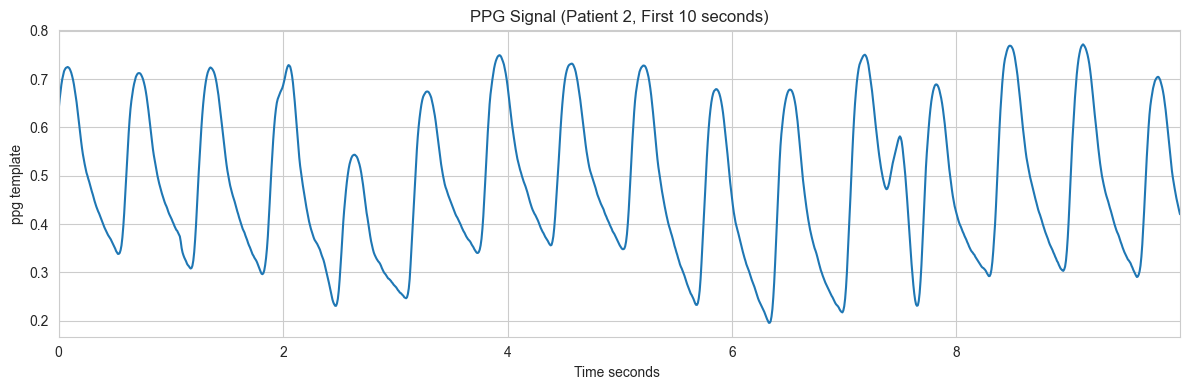

In [6]:
duration=10 
number_of_samples=duration*FS
time=example_signals['Time [s]'][:number_of_samples]
ppg=example_signals['PLETH'][:number_of_samples]

plt.figure(figsize=(12,4))
plt.plot(time,ppg)
plt.title("PPG Signal (Patient 2, First 10 seconds)")
plt.xlabel('Time seconds ')
plt.ylabel('ppg template')
plt.xlim(time.iloc[0],time.iloc[-1])
plt.tight_layout()
plt.show()

In [7]:
ACTIONS={
    0:"Raw Signal",
    1:"Moving Average",
    2:"Savitzky-Golay",
    3:"Butterworth Bandpass"
}

N_ACTIONS=len(ACTIONS)
for action_id,action_name in ACTIONS.items():
    print(f"{action_id}: {action_name}")

0: Raw Signal
1: Moving Average
2: Savitzky-Golay
3: Butterworth Bandpass


In [8]:
def moving_average_filter(signal, window=7):
    kernel = np.ones(window) / window

    filtered = np.convolve(
        signal,
        kernel,
        mode="same"
    )

    return filtered


def savgol_ppg_filter(signal):
    """
    Smooth the signal while preserving the shape of PPG peaks.
    """
    return savgol_filter(
        signal,
        window_length=21,
        polyorder=3
    )


def butterworth_filter(signal, fs=125):
    """
    PPG heart-rate frequency range:
    approximately 0.5 to 5 Hz.
    """

    sos = butter(
        N=4,
        Wn=[0.5, 5.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)


def apply_action(signal, action):
    """
    Apply the filter selected by the RL agent.
    """

    if action == 0:
        return signal.copy()

    elif action == 1:
        return moving_average_filter(signal)

    elif action == 2:
        return savgol_ppg_filter(signal)

    elif action == 3:
        return butterworth_filter(signal, FS)

    else:
        raise ValueError("Invalid action")

In [9]:
def estimate_heart_rate(signal,fs=125):
    signal=np.array(signal,dtype=float)
    normalized_signal=(signal-np.mean(signal))/(np.std(signal)+1e-8)
    
    minimum_distance=int(0.5*fs)
    peaks,_=find_peaks(normalized_signal,distance=minimum_distance,prominence=0.35)
    if len(peaks)<2:
        return np.nan,peaks 
    
    peak_intervals=np.diff(peaks)/fs
    median_interval=np.median(peak_intervals)
    estimated_hr=60/median_interval
    
    
    if  estimated_hr <35 or estimated_hr > 220 : 
        return np.nan ,peaks 
    
    return estimated_hr,peaks 
    

In [10]:
def calculate_noise_score(signal):
    smooth_signal=savgol_filter(signal,window_length=31,polyorder=3)
    high_frequency_part=signal-smooth_signal
    score=(np.std(high_frequency_part)/np.std(signal)+1e-8)
    
    return score

create ppg windows 

In [11]:
def create_window_dataset(all_patient_data):
    rows=[]
    
    for patient_data in all_patient_data:
        patient_id=patient_data['patient_id']
        signals=patient_data['signals'].copy()
        numerics=patient_data['numerics'].copy()
        
        signal_time=pd.to_numeric(signals['Time [s]'],errors='coerce').to_numpy()
        
        ppg_signal=pd.to_numeric(signals['PLETH'],errors='coerce').interpolate().bfill().ffill().to_numpy()
        
        numeric_time=pd.to_numeric(numerics['Time [s]'],errors='coerce').to_numpy()
        
        reference_pulse=pd.to_numeric(numerics['PULSE'],errors='coerce').to_numpy()
        for start in range(0,len(ppg_signal)-WINDOW_SIZE+1,STEP_SIZE):
            end=start+WINDOW_SIZE
            window_ppg=ppg_signal[start:end]
            window_time=signal_time[start:end]
            
            start_time=signal_time[start]
            end_time=signal_time[end-1]
            
            mask=(numeric_time>=start_time)&(numeric_time<=end_time)
            
            pulse_values=reference_pulse[mask]
            pulse_values=pulse_values[np.isfinite(pulse_values)]
            
            if len(pulse_values)==0:
                continue
            
            reference_hr=np.median(pulse_values)
            
            if not 35 <= reference_hr <= 220:
                continue
            
            noise_score=calculate_noise_score(window_ppg)
            rows.append({
                "patient_id":patient_id,
                "start_time":start_time,
                "end_time":end_time,
                "mid_time":window_time[WINDOW_SIZE//2],
                "ppg_signal":window_ppg,
                "reference_hr":reference_hr,
                "noise_score":noise_score
            })
    return pd.DataFrame(rows) 



window_df=create_window_dataset(all_patient_data)
print(len(window_df)) 
display(window_df.drop(columns=['ppg_signal']).head(10))      

593


,patient_id,start_time,end_time,mid_time,reference_hr,noise_score
0,1,0.0,7.992,4.0,93.0,0.121155
1,1,4.0,11.992,8.0,94.0,0.123468
2,1,8.0,15.992,12.0,94.0,0.120951
3,1,12.0,19.992,16.0,94.0,0.119533
4,1,16.0,23.992,20.0,94.0,0.123212
5,1,20.0,27.992,24.0,94.0,0.126791
6,1,24.0,31.992,28.0,94.0,0.128007
7,1,28.0,35.992,32.0,94.0,0.130413
8,1,32.0,39.992,36.0,94.0,0.133665
9,1,36.0,43.992,40.0,94.0,0.134126


In [14]:
STATE_NAMES={
    0:"Low Noise",
    1:"Medium Noise",
    2:"High Noise"} 


q1=window_df["noise_score"].quantile(0.33)
q2=window_df['noise_score'].quantile(0.33)

def noise_to_state(noise_score):
    if noise_score <= q1 : 
        return 0 
    
    elif noise_score <= q2 :
        return 1 
    else : 
        return 2 
    
window_df['state'] =window_df['noise_score'].apply(noise_to_state)

window_df['state_name']=window_df['state'].map(STATE_NAMES)
print("First threshold:",round(q1,4))
print("Second threshold:",round(q2,4))

print(window_df['state_name'].value_counts())

First threshold: 0.0711
Second threshold: 0.0711
state_name
High Noise    397
Low Noise     196
Name: count, dtype: int64


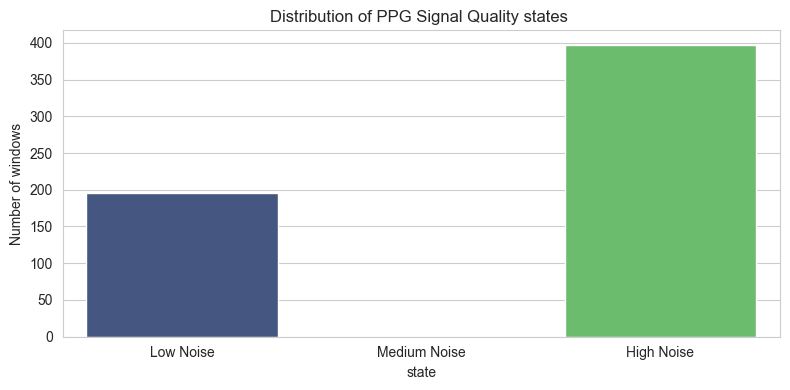

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=window_df,x='state_name',order=['Low Noise','Medium Noise','High Noise'],palette='viridis')
plt.title("Distribution of PPG Signal Quality states ")
plt.xlabel('state')
plt.ylabel('Number of windows')
plt.tight_layout()
plt.show()

In [16]:
def calculate_reward(ppg_window,action,reference_hr):
    filtered_signal=apply_action(ppg_window,action)
    estimated_hr,peaks=estimate_heart_rate(filtered_signal,FS)
    
    if np.isnan(estimated_hr):
        return -50.0 ,np.nan
    error=abs(estimated_hr-reference_hr)
    
    error=min(error,50)
    reward =-error 
    return reward ,estimated_hr 

Precomputed error 